## Decision Trees
Decision trees can be very powerful machine learning tools.  One of their biggest advantages is that they are easy to understand.  When given to employees, for example, they can illustrate policies through pictures.  Such an approach is much more memorable than using words.

### Business Example: Customer Lending
Decision trees can be used to do more than illustrate a policy.  Within the realm of machine learning, they can also be used to understand--given a set of data--what policies the company is ACTUALLY following.  As an example within a bank, suppose the loan approval policy regarding a loan is the following:
* if the customer has a credit score >= 600
  * if the customers' savings is 25% or more of the requested loan, approve the loan
  * otherwise, reject the loan
* otherwise, 
  * if the customers' savings is 50% or more of the requested loan, approve the loan
  * otherwise, reject the loan

The company would obviously have the records of all loan applications, including the resulting decision on the loan.  Using sklearn and decision trees, therefore, it should be straightforward to determine if employees are following the official policy.

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt

df = pd.read_csv('loans.csv')

In [8]:
df.shape


(5262, 5)

In [9]:
df.columns

Index(['CreditScore', 'Savings', 'LoanRequested', 'City', 'Decision'], dtype='object')

### Swim in the Data


In [10]:
df.head()

,CreditScore,Savings,LoanRequested,City,Decision
0,793,77919,256567,Wilmington,1
1,734,83266,246000,Wilmington,1
2,756,32234,248178,Wilmington,0
3,724,75237,221990,Newark,1
4,666,57595,367588,Newark,0


In [12]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
CreditScore,5262.0,575.656024,159.102461,300.0,437.00,576.0,716.00,850.0
Savings,5262.0,49816.439567,20232.771793,-12680.0,36504.25,49641.0,63562.75,129715.0
LoanRequested,5262.0,299887.209806,99241.686013,571.0,232228.00,299836.0,369858.75,637847.0
Decision,5262.0,0.094641,0.292746,0.0,0.00,0.0,0.00,1.0


The decision column was coded as accepted = 1 and rejected = 0.  For that reason, the mean value for decision is the percentage of time the bank approved loans.  The 0.094641 (about 9.5 percent) value seems very low. Are we just being tough?

### Feature Engineering
Because our policy considers the percentage of savings versus the loan amount, let's feature engineer a column that represents that amount:

In [13]:
df['percent'] = df['Savings'] / df['LoanRequested']

Let's break down the descriptives by city:

In [14]:
df.groupby('City').describe().transpose()

City                        Newark     Wilmington
CreditScore   count    1296.000000    3966.000000
              mean      574.881173     575.909228
              std       159.529772     158.981910
              min       301.000000     300.000000
              25%       439.000000     436.000000
              50%       574.500000     577.500000
              75%       712.000000     716.000000
              max       849.000000     850.000000
Savings       count    1296.000000    3966.000000
              mean    49830.795525   49811.748361
              std     19755.601356   20388.729767
              min    -10702.000000  -12680.000000
              25%     37055.000000   36407.500000
              50%     49443.500000   49701.000000
              75%     63346.750000   63583.250000
              max    129715.000000  125653.000000
LoanRequested count    1296.000000    3966.000000
              mean   297010.883488  300827.128845
              std     96279.916552  100184.547869
              min       571.000000    1190.000000
              25%    231276.250000  232307.000000
              50%    297284.000000  300684.500000
              75%    368545.000000  371010.250000
              max    616668.000000  637847.000000
Decision      count    1296.000000    3966.000000
              mean        0.118056       0.086989
              std         0.322798       0.281855
              min         0.000000       0.000000
              25%         0.000000       0.000000
              50%         0.000000       0.000000
              75%         0.000000       0.000000
              max         1.000000       1.000000
percent       count    1296.000000    3966.000000
              mean        0.279494       0.225138
              std         2.828395       0.783011
              min        -0.030404      -0.068443
              25%         0.114866       0.114763
              50%         0.169165       0.166604
              75%         0.235918       0.235927
              max       101.793345      39.515126

The above analysis indicates that loans for people living in Wilmington are approved 8.7% of the time, but Newark loans are approved 11.8% of the time.  This doesn't necessarily mean bias, of course, because the people living in Wilmington may be less qualified than people living in Newark.  

If we look at the credit score, the values for the two cities are very close.  The saving values are almost identical. That seems to indicate that across the two cities, people have about the same qualififcations when they apply for a loan. HOWEVER, Newark residents have almost 28\% of savings versus the loan; Wilmington residents have only 22.5\% of the loan amount in savings.  Hmmmmmmmmm......the above analysis suggests digging in a little further.

One approach is to have sklearn (short for scikit-learn) generate a decision tree for the two cities.  We can then compare the two and see if the same criteria are being used to evaluate loans. 

Let's start by breaking up our data into X and Y dataframes, which will be required for the decision tree.  

In [50]:
df.columns

Index(['CreditScore', 'Savings', 'LoanRequested', 'City', 'Decision',
       'percent'],
      dtype='object')

### Creating Decision Tree based on Credit Score and City

Let's start by creating a simple decision tree that includes only our credit score and the city.  This will allow us to determine if different city locations are using credit scores in a different way. Because the city is a text field (and we cannot use text fields directly), we have to create a binary variable that represents the two cities.  For our purposes, Newark will equal 0 and Wilmington will equal 1.

In [51]:
df.head()

,CreditScore,Savings,LoanRequested,City,Decision,percent
0,793,77919,256567,Wilmington,1,0.303698
1,734,83266,246000,Wilmington,1,0.338480
2,756,32234,248178,Wilmington,0,0.129883
3,724,75237,221990,Newark,1,0.338921
4,666,57595,367588,Newark,0,0.156684


### Set up X and Y

**Set up the dependent variable (Y)**

In [52]:
Y = df['Decision'].copy() # Y is the whether the loan was approved

**Create binary variable for City**

In [53]:
# CityCode = 0 if city is Newark
# CityCode = 1 if city is Wilmington
df.loc[df['City'] == 'Newark', 'CityCode'] = 0 # sets Newark to 0
df.loc[df['City'] == 'Wilmington', 'CityCode'] = 1 # sets Wilmington to 1

**Set up X so that it includes only the two features that we want:**

In [54]:
X = df[['CreditScore', 'CityCode']]

In [55]:
X['CityCode'].value_counts()

1.0    3966
0.0    1296
Name: CityCode, dtype: int64

In [56]:
Y.value_counts()

0    4764
1     498
Name: Decision, dtype: int64

In [57]:
Y.isnull().sum()

0

In [58]:
X.isnull().sum()

CreditScore    0
CityCode       0
dtype: int64

In [59]:
X.columns

Index(['CreditScore', 'CityCode'], dtype='object')

## Decision Tree

In [60]:
# Do a decision tree for all loans....let's see what the overall policy is as a baseline
# max_depth:  the length of the longest path from the tree root to a leaf

clf = tree.DecisionTreeClassifier(max_depth=2, random_state = 0)
clf = clf.fit(X, Y)

[Text(0.5, 0.8333333333333334, 'CreditScore <= 650.5\ngini = 0.171\nsamples = 5262\nvalue = [4764, 498]'),
 Text(0.25, 0.5, 'CityCode <= 0.5\ngini = 0.043\nsamples = 3321\nvalue = [3248, 73]'),
 Text(0.125, 0.16666666666666666, 'gini = 0.109\nsamples = 811\nvalue = [764, 47]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.021\nsamples = 2510\nvalue = [2484, 26]'),
 Text(0.75, 0.5, 'CreditScore <= 848.5\ngini = 0.342\nsamples = 1941\nvalue = [1516, 425]'),
 Text(0.625, 0.16666666666666666, 'gini = 0.34\nsamples = 1929\nvalue = [1510, 419]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.5\nsamples = 12\nvalue = [6, 6]')]

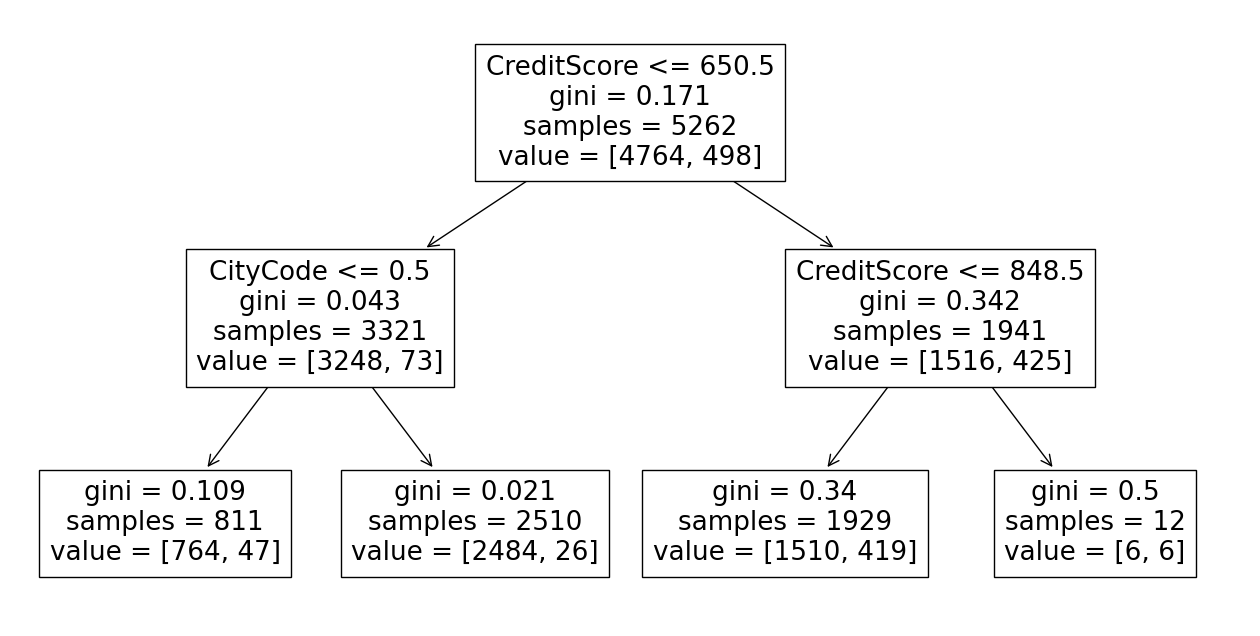

In [61]:
plt.figure(figsize=(16,8))
tree.plot_tree(clf,feature_names=['CreditScore', 'CityCode'])

Examine the above tree **VERY CAREFULLY**! It is a very simple example of what we will be doing, so understanding it is critical.  Note that because there is a random element to decision trees, the numbers may differ in the following explanation. Let's assume we have a person with a credit score of 660 and lives in Newark.

Left path is the True path.
Right path is the False path.
value=[0,1]
value=[number of approved loan requests, number of accepted loan requests]

* Within each node, the criteria are listed first.  The gini value is the measure of entropy.  The samples indicate the number of customers at the point under consideration.  The value indicates [loan rejected, loan approved].  Overall, 4764/(4764+498) (90.5%) of all customers are _rejected_ and  498/(4764+498) (9.5%) of all customers are _approved_.

* **PATH 1**  (the first True branch): For CreditScore less than 650.5,  3248/(3248+73) (97.8\%) are rejected and 73/(3248+73) (2.2\%) are approved. Compare this to 90.5\% who were rejected overall.  Conclusion: smaller CreditScore decreases your chances of getting the loan.
  * For customers who have a CityCode <= 0.5 (The True path: customers from Newark) ,  764/(764+47) (94.2\%) are rejected and 47/(764+47) (5.8\%) are approved.
  * For customers who have a CityCode > 0.5 (The False path: customers from Wilmington),  2484/(2484+26) (98.9\%) are rejected and 26/(2484+26) (1.1\%) are approved.


  
* **PATH 2**  (the first False branch): For CreditScore greater than 650.5, 1516/(1516+425) (78.1\%) are rejected and 425/(1516+425) (21.9\%) are approved . This indicates that with higher CreditScore, you have a lower chance of rejection.
  * For customers who have CreditScore between 650.5 and 848.5 (The True path) ,  1510/(1510+419) (78.3\%) are rejected and 419/(1510+419) (21.7\%) are approved.  
  * For customers who have CreditScore greater than 848.5 (The False path), 6/(6+6) (50\%) are rejected and 6/(6+6) (50\%) are approved
  
If you examine the final gini values, the best categorization occurs when the CreditScore is less than 650.5 and the customer is from Wilmingtons (gini = 0.021).  Apparently, rejecting the application under these circumstances is easy.  The toughest decision, however, occurs when the CreditScore is greater than 848.5 (gini = 0.392). 




Now confirm the following:
* A person with a 600 credit score and lives in Wilmington has an almost 2484/(2484+26) = 99\% chance of rejection
* A person with a 850 credit score has a 6/(6+6)= 50\% chance of acceptance, regardless of where he lives



# The Role of Gini
Gini is an entropy score of disparity, or difference.  If you have two groups of interest, the maximum amount of difference would be if you had 50\% of one type and 50\% of the other.  The gini coefficient would therefore be:
<br><br>`gini = 1 - [(0.50)**2 + (0.50)**2)] = 0.50`

In the first node of our tree, the gini calculation looks like this:
<br><br>`pct_declined = 4764/(498+4764)`
<br>`pct_approved = 498/(498+4764)`
<br>`gini = 1 - [pct_declined**2 + pct_approved**2]`
<br>`gini = 1 - [0.9054**2 + 0.0946**2]`
<br>`gini = 1 - [0.8197 + 0.009] = 0.171`

<br>You can see this is the value listed for gini in the first node.

**Explore more:**
* Do the calculation for the remaining two gini values. 
* Given the gini values, has entropy increased or decreased?
* Does city help us understand loan policies?  Why or why not?